**Importing Libraries**

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

**Load dataset**

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(df.shape)

(20640, 9)


**Data cleaning and preprocessing**

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (20640, 9)


In [5]:
print("\nFeature Names:", df.columns)


Feature Names: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Check missing values
print(df.isnull().sum())

# No missing values in this dataset

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


**Features and target**

In [8]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Scale features**

In [9]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 16512, Test samples: 4128


**Model Creation and Training**

In [12]:
# Initialize model
etr = ExtraTreesRegressor(random_state=42)

In [13]:
# Fit model
etr.fit(X_train, y_train)

ExtraTreesRegressor(random_state=42)

**Predictions**

In [14]:
y_pred = etr.predict(X_test)

**Model Evaluation**

In [15]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [16]:
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error (MSE): 0.2539
Root Mean Squared Error (RMSE): 0.5039
Mean Absolute Error (MAE): 0.3270
R^2 Score: 0.8062


**Hyperparameter Tuning with GridSearchCV**

In [17]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2", None]  # removed 'auto'
}

In [18]:
grid_search = GridSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring="r2"
)

In [19]:
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [20]:
# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"R^2 Score after tuning: {r2_score(y_test, y_pred_best):.4f}")

R^2 Score after tuning: 0.8198


**Feature Importance Visualization**

In [21]:
importances = best_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

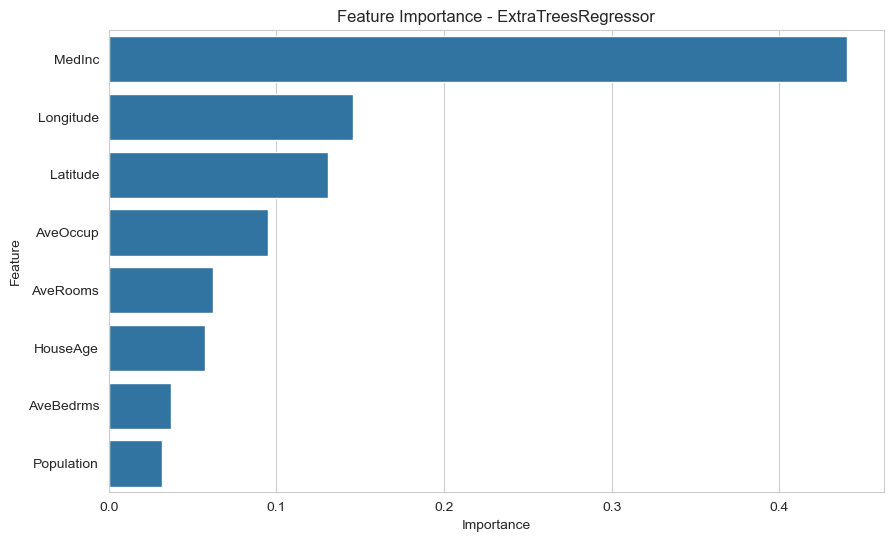

In [22]:
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Feature Importance - ExtraTreesRegressor")
plt.show()

**Learning Curve**

In [23]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_scaled, y, cv=5, scoring='r2', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

In [24]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

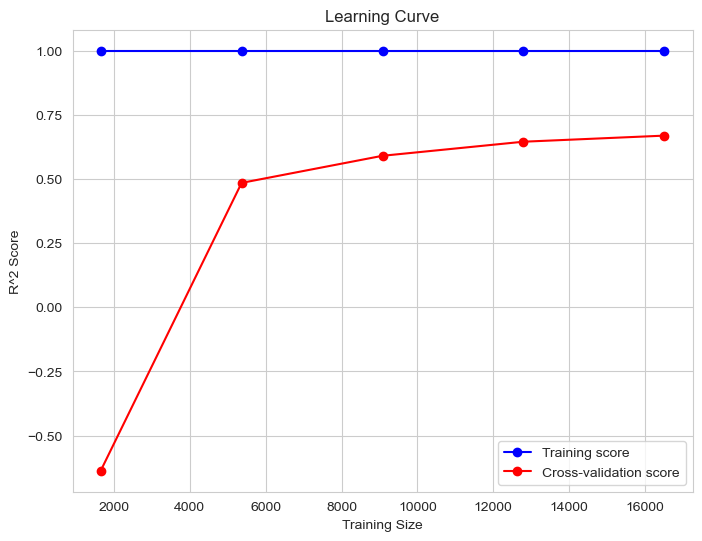

In [25]:
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-validation score')
plt.title('Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('R^2 Score')
plt.legend(loc='best')
plt.show()

**ExtraTreesRegressor**  
- **Type**: Ensemble of extremely randomized trees for regression.  
- **When to use**: Tabular regression tasks with numerical or categorical features. Good for high-dimensional datasets.  
- **Advantages**:  
     - Handles high-dimensional data well.  
     - Less prone to overfitting due to ensemble averaging.  
     - Faster than Random Forest due to randomized splits.  

- **Disadvantages**:  
     - Less interpretable than a single decision tree.  
     - Can be memory-intensive with large datasets.  

- **Key Hyperparameters**:  
     - `n_estimators`: Number of trees. More trees = better performance but slower.  
     - `max_depth`: Maximum tree depth. Prevents overfitting.  
     - `min_samples_split` & `min_samples_leaf`: Control minimum samples to split and at leaf.  
     - `max_features`: Number of features considered at each split.  
- **Practical tips**:  
     - Use default `n_estimators=100` initially.  
     - Tune `max_depth` and `min_samples_leaf` for large datasets to reduce overfitting.  
     - Feature scaling is optional.  
     - Use GridSearchCV or RandomizedSearchCV for tuning hyperparameters efficiently.